# Phase 1: Binary Classification Pipeline — KNN

This notebook implements the complete binary classification pipeline for MNIST digits **0 vs 1** using our custom K-Nearest Neighbors classifier.

**Pipeline steps:**
1. Load & preprocess data
2. Extract features using **Flatten**, **HOG**, and **PCA**
3. Tune K on the validation set for each feature method
4. Compare results across feature methods
5. Final evaluation on the test set with the best configuration
6. Visualizations (confusion matrix, accuracy curves, sample images)

## 0. Imports & Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.features.mnist_features import  load_mnist, select_binary_classes, split_data, balance_binary_classes, normalize_data, build_features, class_distribution
from src.analysis.evaluation import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from src.analysis.testing import evaluate_k_values, test_best_model, run_pipeline_checks
from src.analysis.analysis import (
    plot_tuning_curves, plot_confusion_matrices, plot_metric_comparison, 
    summarize_results, show_top_config, plot_roc_curves, 
    plot_precision_recall_curves, plot_probability_distribution, plot_pca_2d
)
from src.models.knn_model import KNNClassifier

All imports successful.


## 1. Load & Preprocess Data

In [10]:
# Load the full MNIST dataset
x_all, y_all = load_mnist('../../data/mnist.npz')
print(f'Full dataset shape: {x_all.shape}, Labels shape: {y_all.shape}')

# Select binary classes 0 and 1
class_a, class_b = 0, 1
x_binary, y_binary = select_binary_classes(x_all, y_all, class_a, class_b)
print(f'Binary subset (classes {class_a} & {class_b}): {x_binary.shape[0]} samples')
print('Class distribution:', class_distribution(y_binary))

Full dataset shape: (70000, 28, 28), Labels shape: (70000,)
Binary subset (classes 0 & 1): 14780 samples
Class distribution: {0: 6903, 1: 7877}


### 1.1 Visualize Sample Images

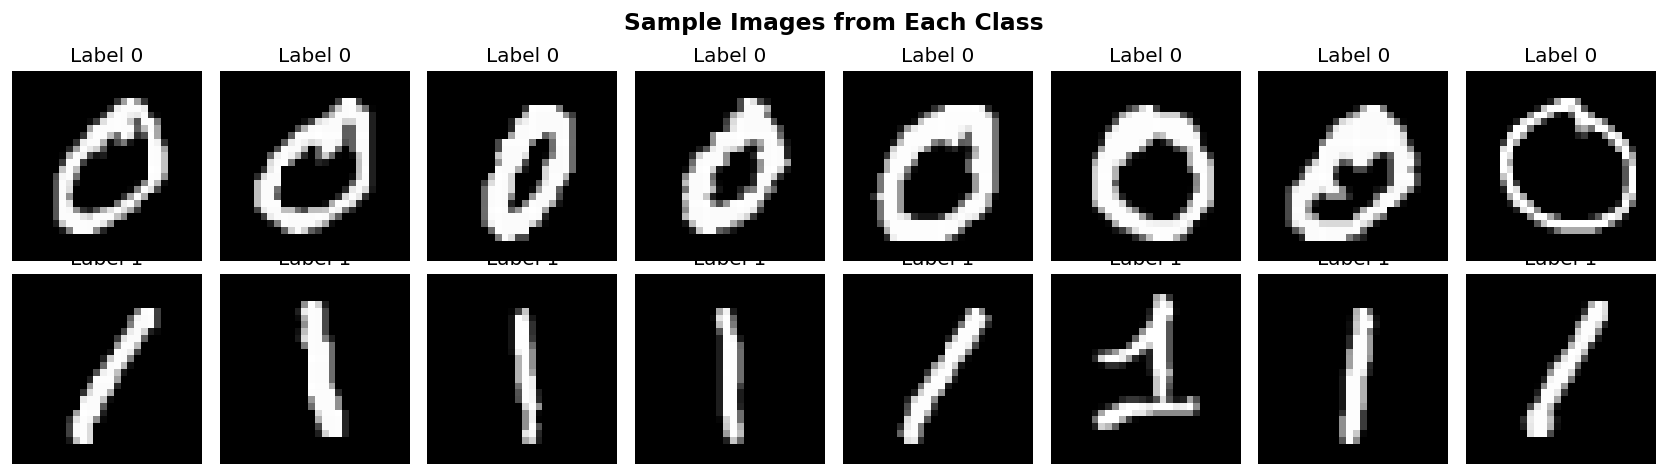

In [11]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for row, label in enumerate([class_a, class_b]):
    idxs = np.where(y_binary == label)[0][:8]
    for col, idx in enumerate(idxs):
        axes[row, col].imshow(x_binary[idx], cmap='gray')
        axes[row, col].set_title(f'Label {label}')
        axes[row, col].axis('off')
fig.suptitle('Sample Images from Each Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.2 Train / Validation / Test Split

In [12]:
x_train, y_train, x_val, y_val, x_test, y_test = split_data(
    x_binary, y_binary, test_size=0.15, val_size=0.15, random_state=42
)
print(f'Train: {len(y_train)},  Val: {len(y_val)},  Test: {len(y_test)}')
print('Train distribution:', class_distribution(y_train))

# Run pipeline integrity checks
run_pipeline_checks(x_train, y_train, x_test, y_test, x_val, y_val)

# Run pipeline integrity checks
run_pipeline_checks(x_train, y_train, x_test, y_test, x_val, y_val)

Train: 10346,  Val: 2217,  Test: 2217
Train distribution: {0: 4764, 1: 5582}


### 1.3 Balance Training Set

In [13]:
x_train, y_train = balance_binary_classes(x_train, y_train, method='undersample', random_state=42)
print(f'Balanced train size: {len(y_train)}')
print('Balanced distribution:', class_distribution(y_train))

Balanced train size: 9528
Balanced distribution: {0: 4764, 1: 4764}


### 1.4 Normalize Pixel Values

In [14]:
x_train = normalize_data(x_train)
x_val   = normalize_data(x_val)
x_test  = normalize_data(x_test)
print(f'Pixel range after normalization: [{x_train.min():.1f}, {x_train.max():.1f}]')

Pixel range after normalization: [0.0, 1.0]


## 2. Feature Extraction

We compare three feature extraction methods:
- **Flatten**: Reshape each 28×28 image into a 784-dimensional vector
- **HOG**: Histogram of Oriented Gradients – captures edge/shape information
- **PCA**: Principal Component Analysis – reduces dimensionality while preserving 95% variance

In [15]:
feature_methods = ['flatten', 'hog', 'pca']
features = {}

for method in feature_methods:
    train_f, val_f, test_f = build_features(method, x_train, x_val, x_test, pca_components=0.95, random_state=42)
    features[method] = (train_f, val_f, test_f)
    print(f'{method.upper():>7s} -> {train_f.shape[1]} features')

FLATTEN -> 784 features
    HOG -> 1296 features
    PCA -> 97 features


### 2.1 PCA - Data Visualization

We visualize the distribution of classes 0 and 1 in the 2D space of the first two principal components.

In [ ]:
train_pca, _, _ = features['pca']
plot_pca_2d(train_pca, y_train, title='MNIST Binary (0 vs 1) - PCA Cluster Visualization')

## 3. Hyperparameter Tuning — Finding Best K per Feature Method

For each feature method we evaluate K ∈ {1, 3, 5, 7, 9, 11} on the **validation** set.

In [16]:
k_values = [1, 3, 5, 7, 9, 11]
all_results = {}   # method -> {k: metrics}
best_ks = {}       # method -> best k

for method in feature_methods:
    train_f, val_f, _ = features[method]
    print(f'\n===== {method.upper()} features =====')
    results, best_k = evaluate_k_values(train_f, y_train, k_values=k_values)
    all_results[method] = results
    best_ks[method] = best_k
    print(f'Best K for {method.upper()}: {best_k}  (val accuracy = {results[best_k]["val_accuracy"]:.4f})')


===== FLATTEN features =====
Evaluating KNN with k=1 using 5-Fold CV...
Evaluating KNN with k=3 using 5-Fold CV...
Evaluating KNN with k=5 using 5-Fold CV...
Evaluating KNN with k=7 using 5-Fold CV...
Evaluating KNN with k=9 using 5-Fold CV...
Evaluating KNN with k=11 using 5-Fold CV...
Best K for FLATTEN: 3  (val accuracy = 0.9971)

===== HOG features =====
Evaluating KNN with k=1 using 5-Fold CV...
Evaluating KNN with k=3 using 5-Fold CV...
Evaluating KNN with k=5 using 5-Fold CV...
Evaluating KNN with k=7 using 5-Fold CV...
Evaluating KNN with k=9 using 5-Fold CV...
Evaluating KNN with k=11 using 5-Fold CV...
Best K for HOG: 11  (val accuracy = 0.9949)

===== PCA features =====
Evaluating KNN with k=1 using 5-Fold CV...
Evaluating KNN with k=3 using 5-Fold CV...
Evaluating KNN with k=5 using 5-Fold CV...
Evaluating KNN with k=7 using 5-Fold CV...
Evaluating KNN with k=9 using 5-Fold CV...
Evaluating KNN with k=11 using 5-Fold CV...
Best K for PCA: 1  (val accuracy = 0.9925)


### 3.1 Validation Accuracy vs K (All Feature Methods)

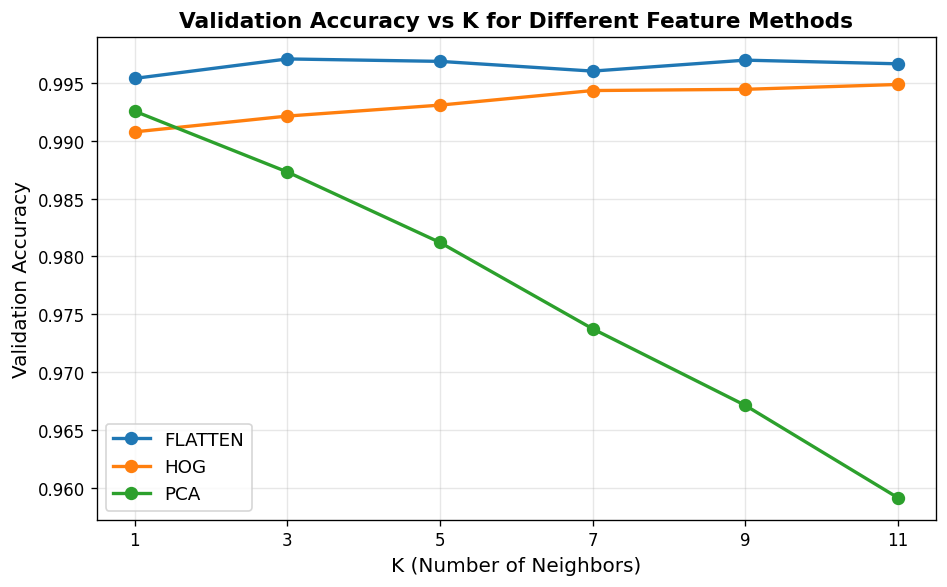

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))
for method in feature_methods:
    accs = [all_results[method][k]['val_accuracy'] for k in k_values]
    ax.plot(k_values, accs, 'o-', label=method.upper(), linewidth=2, markersize=7)

ax.set_xlabel('K (Number of Neighbors)', fontsize=12)
ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('Validation Accuracy vs K for Different Feature Methods', fontsize=13, fontweight='bold')
ax.set_xticks(k_values)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.2 Detailed Validation Metrics (Best K per Method)

In [18]:
print(f'{"Method":<10} {"K":>3}  {"Val Accuracy":>13} {"Train Accuracy":>14}')
print('-' * 45)
for method in feature_methods:
    k = best_ks[method]
    m = all_results[method][k]
    print(f'{method.upper():<10} {k:>3}  {m["val_accuracy"]:>13.4f} {m["train_accuracy"]:>14.4f}')

Method       K   Val Accuracy Train Accuracy
---------------------------------------------
FLATTEN      3         0.9971         0.9983
HOG         11         0.9949         0.9957
PCA          1         0.9925         1.0000


### 3.3 Full K Comparison Table

In [19]:
for method in feature_methods:
    print(f'\n--- {method.upper()} ---')
    print(f'{"K":>3}  {"Val Accuracy":>13} {"Train Accuracy":>14}')
    for k in k_values:
        m = all_results[method][k]
        print(f'{k:>3}  {m["val_accuracy"]:>13.4f} {m["train_accuracy"]:>14.4f}')


--- FLATTEN ---
  K   Val Accuracy Train Accuracy
  1         0.9954         1.0000
  3         0.9971         0.9983
  5         0.9969         0.9982
  7         0.9960         0.9975
  9         0.9970         0.9972
 11         0.9966         0.9969

--- HOG ---
  K   Val Accuracy Train Accuracy
  1         0.9908         1.0000
  3         0.9921         0.9964
  5         0.9931         0.9952
  7         0.9943         0.9953
  9         0.9944         0.9955
 11         0.9949         0.9957

--- PCA ---
  K   Val Accuracy Train Accuracy
  1         0.9925         1.0000
  3         0.9873         0.9966
  5         0.9812         0.9918
  7         0.9738         0.9853
  9         0.9671         0.9784
 11         0.9592         0.9712


## 4. Final Evaluation on Test Set

We train each feature method's best model and evaluate on the **unseen test set**.

In [20]:
test_results_all = {}

for method in feature_methods:
    train_f, _, test_f = features[method]
    k = best_ks[method]
    print(f'\n===== {method.upper()} (K={k}) on TEST set =====')
    model = KNNClassifier(k=k)
    model.train(train_f, y_train)
    result = test_best_model(model, test_f, y_test)
    test_results_all[method] = result
    print(f'  Accuracy:  {result["accuracy"]:.4f}')
    print(f'  Precision: {result["precision"]:.4f}')
    print(f'  Recall:    {result["recall"]:.4f}')
    print(f'  F1 Score:  {result["f1_score"]:.4f}')


===== FLATTEN (K=3) on TEST set =====
Testing best model on the test set...
  Accuracy:  0.9955
  Precision: 0.9955
  Recall:    0.9955
  F1 Score:  0.9955

===== HOG (K=11) on TEST set =====
Testing best model on the test set...
  Accuracy:  0.9941
  Precision: 0.9940
  Recall:    0.9943
  F1 Score:  0.9941

===== PCA (K=1) on TEST set =====
Testing best model on the test set...
  Accuracy:  0.9950
  Precision: 0.9953
  Recall:    0.9948
  F1 Score:  0.9950


### 4.1 Test Set — Comparison Table

In [21]:
print(f'{"Method":<10} {"K":>3}  {"Accuracy":>9} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('-' * 55)
for method in feature_methods:
    k = best_ks[method]
    m = test_results_all[method]
    print(f'{method.upper():<10} {k:>3}  {m["accuracy"]:>9.4f} {m["precision"]:>10.4f} {m["recall"]:>8.4f} {m["f1_score"]:>8.4f}')

Method       K   Accuracy  Precision   Recall       F1
-------------------------------------------------------
FLATTEN      3     0.9955     0.9955   0.9955   0.9955
HOG         11     0.9941     0.9940   0.9943   0.9941
PCA          1     0.9950     0.9953   0.9948   0.9950


### 4.2 ROC and Precision-Recall Curves

We now visualize the trade-offs between True Positive Rate and False Positive Rate (ROC), and Precision and Recall for all feature methods.

In [ ]:
summary_df = summarize_results(list(test_results_all.values()))
summary_df['feature_mode'] = list(test_results_all.keys())

# Plot ROC Curves
plot_roc_curves(summary_df, y_test, pos_label=class_b)
plt.show()

# Plot Precision-Recall Curves
plot_precision_recall_curves(summary_df, y_test, pos_label=class_b)
plt.show()

### 4.2 ROC and Precision-Recall Curves

We now visualize the trade-offs between True Positive Rate and False Positive Rate (ROC), and Precision and Recall for all feature methods.

In [ ]:
summary_df = summarize_results(list(test_results_all.values()))
summary_df['feature_mode'] = list(test_results_all.keys())

# Plot ROC Curves
plot_roc_curves(summary_df, y_test, pos_label=class_b)
plt.show()

# Plot Precision-Recall Curves
plot_precision_recall_curves(summary_df, y_test, pos_label=class_b)
plt.show()

### 4.2 Test Accuracy Comparison (Bar Chart)

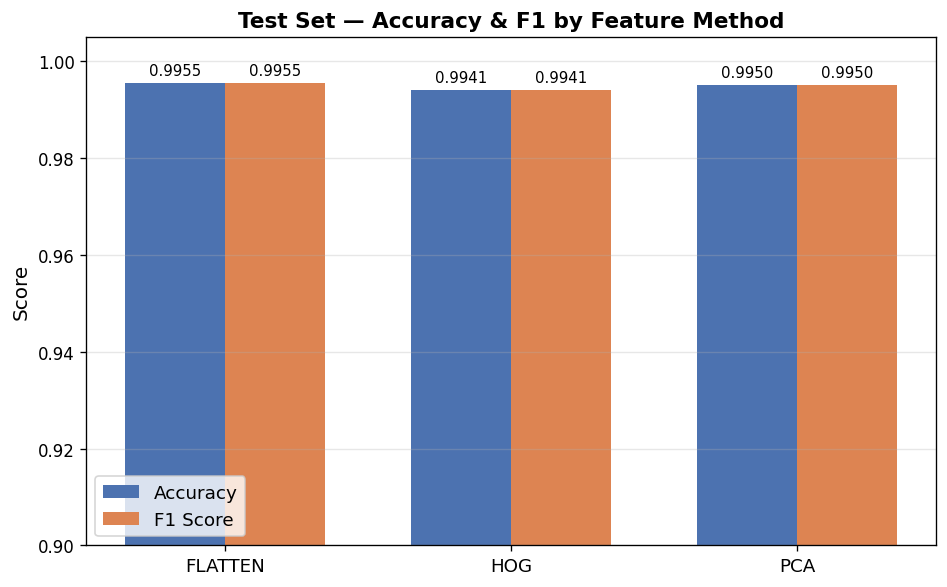

In [22]:
methods_labels = [m.upper() for m in feature_methods]
test_accs = [test_results_all[m]['accuracy'] for m in feature_methods]
test_f1s  = [test_results_all[m]['f1_score'] for m in feature_methods]

x = np.arange(len(methods_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, test_accs, width, label='Accuracy', color='#4C72B0')
bars2 = ax.bar(x + width/2, test_f1s, width, label='F1 Score', color='#DD8452')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Test Set — Accuracy & F1 by Feature Method', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(methods_labels, fontsize=11)
ax.set_ylim(0.9, 1.005)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Confusion Matrices (Test Set)

Visual confusion matrices for each feature extraction method on the test set.

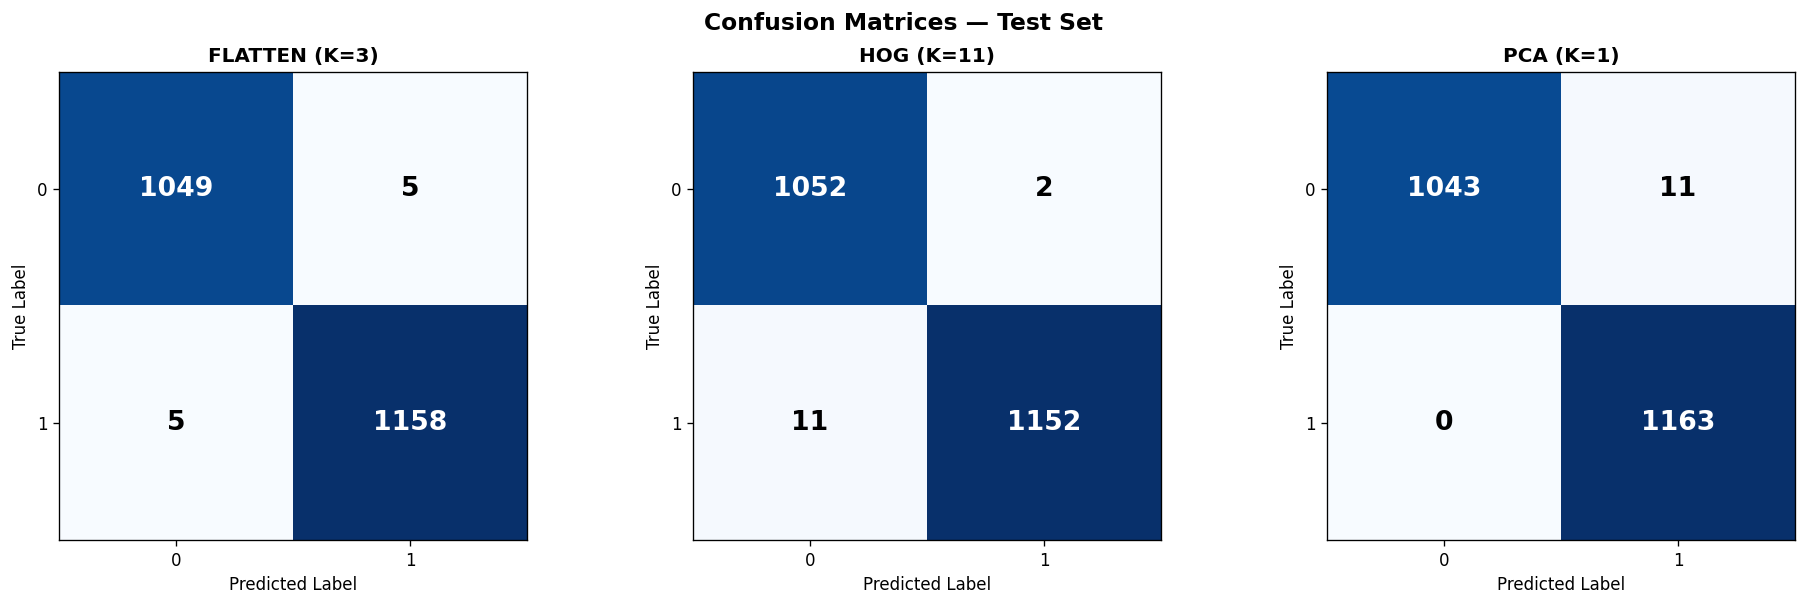

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels = [class_a, class_b]

for ax, method in zip(axes, feature_methods):
    cm = test_results_all[method]['confusion_matrix']
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(f'{method.upper()} (K={best_ks[method]})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    # Annotate cells with counts
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    fontsize=16, fontweight='bold', color=color)

fig.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Misclassified Examples

Showing examples that the best overall model got wrong, so we can understand failure modes.

Best overall: FLATTEN with K=3
Total misclassified: 10 out of 2217


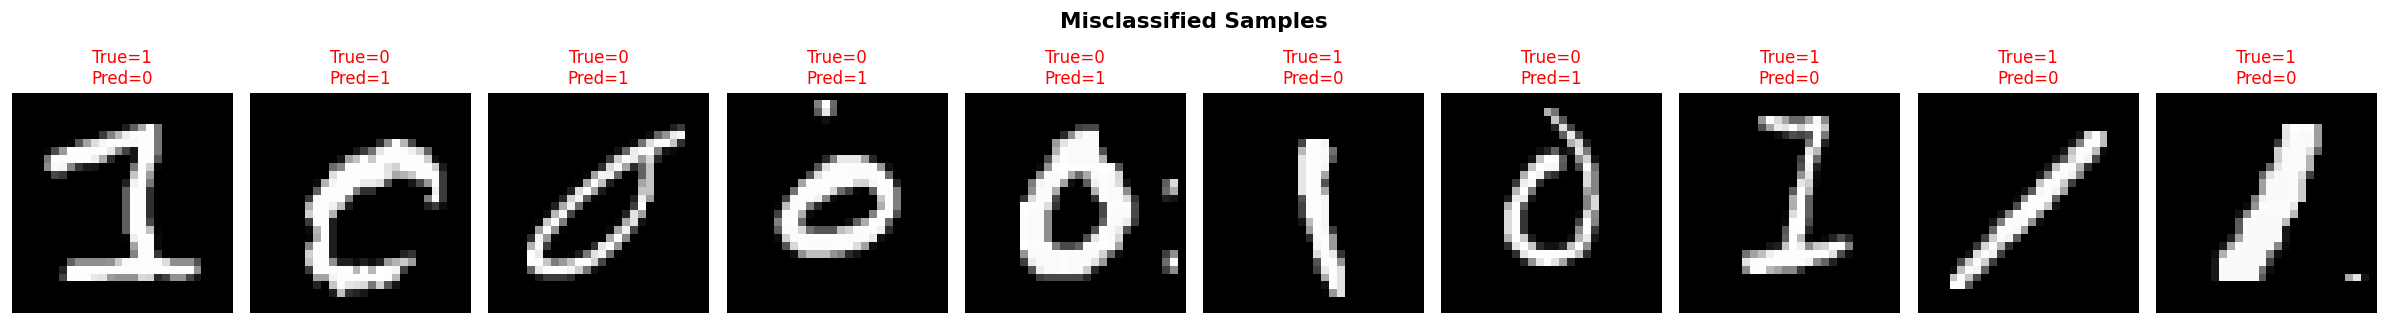

In [24]:
# Pick the best overall method
best_method = max(test_results_all, key=lambda m: test_results_all[m]['accuracy'])
best_k_final = best_ks[best_method]
print(f'Best overall: {best_method.upper()} with K={best_k_final}')

# Get predictions on test set with the best model
train_f, _, test_f = features[best_method]
model = KNNClassifier(k=best_k_final)
model.train(train_f, y_train)
y_pred = model.predict(test_f)

# Find misclassified indices
misclassified = np.where(y_pred != y_test)[0]
print(f'Total misclassified: {len(misclassified)} out of {len(y_test)}')

# Show up to 10 misclassified images
n_show = min(10, len(misclassified))
if n_show > 0:
    fig, axes = plt.subplots(1, n_show, figsize=(2 * n_show, 3))
    if n_show == 1:
        axes = [axes]
    for i, idx in enumerate(misclassified[:n_show]):
        axes[i].imshow(x_test[idx], cmap='gray')
        axes[i].set_title(f'True={y_test[idx]}\nPred={y_pred[idx]}', fontsize=10, color='red')
        axes[i].axis('off')
    fig.suptitle('Misclassified Samples', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No misclassified samples!')

## 7. Summary

In [25]:
print('=' * 60)
print('FINAL SUMMARY')
print('=' * 60)
print(f'Classes: {class_a} vs {class_b}')
print(f'Train size: {len(y_train)} (balanced)  |  Val: {len(y_val)}  |  Test: {len(y_test)}')
print()
print(f'{"Method":<10} {"Best K":>6}  {"Test Acc":>9}  {"Test F1":>8}')
print('-' * 40)
for method in feature_methods:
    k = best_ks[method]
    m = test_results_all[method]
    print(f'{method.upper():<10} {k:>6}  {m["accuracy"]:>9.4f}  {m["f1_score"]:>8.4f}')
print()
print(f'Best overall: {best_method.upper()} with K={best_k_final} '
      f'(Accuracy={test_results_all[best_method]["accuracy"]:.4f})')

FINAL SUMMARY
Classes: 0 vs 1
Train size: 9528 (balanced)  |  Val: 2217  |  Test: 2217

Method     Best K   Test Acc   Test F1
----------------------------------------
FLATTEN         3     0.9955    0.9955
HOG            11     0.9941    0.9941
PCA             1     0.9950    0.9950

Best overall: FLATTEN with K=3 (Accuracy=0.9955)


## 5. Model Diagnostics

### 5.1 Predicted Probability Distribution

We examine the distribution of predicted probabilities for the best model (e.g., FLATTEN) to see how well the classes are separated.

In [ ]:
best_method = 'flatten'
y_probas = test_results_all[best_method]['test_probas']
plot_probability_distribution(y_test, y_probas, pos_label=class_b, title=f'Probability Distribution - {best_method.upper()}')
plt.show()

## 5. Model Diagnostics

### 5.1 Classification Report

We provide a detailed report including precision, recall, and F1-score for each class.

In [ ]:
best_method = show_top_config(summary_df)['feature_mode']
print(f"Classification Report for {best_method.upper()} (K={best_ks[best_method]}):\n")
print(classification_report(y_test, test_results_all[best_method]['test_preds']))

### 5.2 Predicted Probability Distribution

We examine the distribution of predicted probabilities to see how well the classes are separated.

In [ ]:
y_probas = test_results_all[best_method]['test_probas']
plot_probability_distribution(y_test, y_probas, pos_label=class_b, title=f'Probability Distribution - {best_method.upper()}')
plt.show()